# Lab 1 · From arrays to a learning experiment
**BME · MSc Deep Learning · Guided notebook · 9 September 2026**

By the end of this lab, you should be able to:

1. Read an array's shape and data type, and select the values you need.
2. Apply a feature-wise operation to a batch without a Python loop.
3. Explain what a trainable variable, a loss, and a gradient do.
4. Perform one parameter update and inspect a real loss curve.
5. Record an experiment and submit a notebook that another person can rerun.

**How we will work:** follow this notebook with the instructor first.
Then complete **02_BME_DL_Lab1_Assignment.ipynb** independently and submit it to Moodle.
The sections after **End of the guided part** are optional reference material.

## Before you start

Open this `.ipynb` file in [Google Colab](https://colab.research.google.com/) using **Upload notebook**.
Save your own copy. Use a Python runtime; a CPU is sufficient. Run cells from top to bottom with **Shift+Enter**.

Run the setup cell below first. It records the versions actually in your session.
Use Colab's existing packages when the cell succeeds. If an import fails, ask the instructor before changing packages.
A missing-package fallback is provided in the teaching guide.

The core code was tested with TensorFlow 2.20.0 on a CPU. This is a tested version, not a claim about the newest release.
Colab's installed versions and available resources can change.

In [1]:
import sys
import re
from pathlib import Path
from datetime import datetime, timezone
from uuid import uuid4
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorboard
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("TensorBoard:", tensorboard.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Visible GPUs:", len(tf.config.list_physical_devices("GPU")))
print("A CPU is sufficient for every exercise in this lab.")

Python: 3.12.13
NumPy: 2.5.3
TensorFlow: 2.20.0
TensorBoard: 2.20.0
Matplotlib: 3.11.1
Visible GPUs: 0
A CPU is sufficient for every exercise in this lab.


## 1 · A short Python refresher

A function returns a value that later code can use. Indentation defines its body.
A list stores a sequence of objects; a NumPy array supports numerical operations on its entries.

**Predict before running:** will multiplying a list by 2 double its values?

In [2]:
values = [1.0, 2.0, 3.0]
print("Python list * 2:", values * 2)

def double_values(values):
    return np.asarray(values, dtype=np.float32) * 2

print("NumPy array * 2:", double_values(values))
for index, value in enumerate(values):
    print(f"Entry {index}: {value}")

Python list * 2: [1.0, 2.0, 3.0, 1.0, 2.0, 3.0]
NumPy array * 2: [2. 4. 6.]
Entry 0: 1.0
Entry 1: 2.0
Entry 2: 3.0


## 2 · Think in samples and features

Here each row represents one synthetic speech recording.
The columns are **pitch in Hz** and a made-up **energy feature**.
These values illustrate array operations; they are not research measurements.

`shape` gives the axis lengths, `ndim` the number of axes, and `dtype` the element type.
Use explicit types: `np.float32` for these features, `np.int32` for integer labels,
and often `np.uint8` for raw 0–255 image pixels. Python `float` normally produces a NumPy `float64` array.

**Predict:** how many samples, features, and individual numbers are there?

In [3]:
features = np.array([
    [100.0, 0.2],
    [120.0, 0.4],
    [140.0, 0.6],
    [160.0, 0.8],
], dtype=np.float32)
print(features)
print("shape:", features.shape, "| ndim:", features.ndim)
print("size:", features.size, "| dtype:", features.dtype)

[[100.    0.2]
 [120.    0.4]
 [140.    0.6]
 [160.    0.8]]
shape: (4, 2) | ndim: 2
size: 8 | dtype: float32


## 3 · Select data and reduce an axis

Indexing starts at zero. A slice excludes its stop index, so `[:2]` selects the first two rows.
Negative indices count from the end.

For our `(samples, features)` array, a mean over `axis=0` combines samples and leaves one result per feature.
A mean over `axis=1` combines features within each sample.
A row mean mixes different physical quantities here, so it is a shape demonstration, not a useful speech feature.

In [4]:
print("First two samples:\n", features[:2])
print("Last sample:", features[-1])
print("Pitch column:", features[:, 0], features[:, 0].shape)
print("Pitch as a column matrix:\n", features[:, 0:1], features[:, 0:1].shape)
print("One mean per feature:", features.mean(axis=0))
print("One mean per sample:", features.mean(axis=1))

First two samples:
 [[100.    0.2]
 [120.    0.4]]
Last sample: [160.    0.8]
Pitch column: [100. 120. 140. 160.] (4,)
Pitch as a column matrix:
 [[100.]
 [120.]
 [140.]
 [160.]] (4, 1)
One mean per feature: [130.    0.5]
One mean per sample: [50.1 60.2 70.3 80.4]


## 4 · Broadcasting and feature scaling

Subtracting a `(1, 2)` mean from a `(4, 2)` batch applies the corresponding mean to each row.
Broadcasting compares shapes from the right: aligned lengths must match or one must be 1.

Standardisation subtracts a feature's mean and divides by its standard deviation.
The small lower bound on the scale avoids division by zero for a constant feature.
NumPy's default standard deviation uses `ddof=0`.

**For modelling:** estimate preprocessing statistics from training data.
Apply those same statistics to validation and test data.

In [5]:
train_mean = features.mean(axis=0, keepdims=True)
train_scale = np.maximum(
    features.std(axis=0, keepdims=True), np.float32(1e-6)
)
scaled = (features - train_mean) / train_scale
print("Mean shape:", train_mean.shape, "| scale shape:", train_scale.shape)
print("Scaled training data:\n", scaled)
print("Scaled feature means:", scaled.mean(axis=0))

new_recordings = np.array([[180.0, 1.0]], dtype=np.float32)
print("New sample, using training statistics:",
      (new_recordings - train_mean) / train_scale)

Mean shape: (1, 2) | scale shape: (1, 2)
Scaled training data:
 [[-1.3416 -1.3416]
 [-0.4472 -0.4472]
 [ 0.4472  0.4472]
 [ 1.3416  1.3416]]
Scaled feature means: [0. 0.]
New sample, using training statistics: [[2.2361 2.2361]]


## 5 · Two different kinds of multiplication

`*` multiplies matching entries, with broadcasting when appropriate.
`@` performs matrix multiplication; the inner dimensions must match.

A `(4, 2)` feature batch multiplied by `(2, 1)` weights gives `(4, 1)` predictions.
Keep track of shapes before interpreting the numbers.

In [6]:
print("Rescale each feature:\n", scaled * np.array([2.0, 0.5], dtype=np.float32))
weights = np.array([[0.5], [-0.25]], dtype=np.float32)
print("Matrix product shape:", (scaled @ weights).shape)

# This error is intentional and caught, so Run all can continue.
try:
    _ = scaled @ np.ones((3, 1), dtype=np.float32)
except ValueError as error:
    print("Expected shape mismatch:", str(error).splitlines()[0])

Rescale each feature:
 [[-2.6833 -0.6708]
 [-0.8944 -0.2236]
 [ 0.8944  0.2236]
 [ 2.6833  0.6708]]
Matrix product shape: (4, 1)
Expected shape mismatch: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)


## 6 · From NumPy arrays to TensorFlow tensors

A tensor also has a shape and a data type. TensorFlow additionally supports automatic differentiation.
`tf.constant` holds a tensor value; `tf.Variable` provides assignable state for a parameter.

The next example has two feature weights and one bias. It only calculates predictions; no training has happened.
**Question:** what changes when we assign a different bias?

In [7]:
X_tf = tf.convert_to_tensor(scaled, dtype=tf.float32)
W_tf = tf.Variable([[0.5], [-0.25]], dtype=tf.float32)
bias_tf = tf.Variable(0.0, dtype=tf.float32)
predictions = tf.matmul(X_tf, W_tf) + bias_tf
print("Tensor:", X_tf.shape, X_tf.dtype)
print("Predictions:\n", predictions.numpy())
bias_tf.assign(1.0)
print("After changing only the bias:\n", (X_tf @ W_tf + bias_tf).numpy())

Tensor: (4, 2) <dtype: 'float32'>
Predictions:
 [[-0.3354]
 [-0.1118]
 [ 0.1118]
 [ 0.3354]]
After changing only the bias:
 [[0.6646]
 [0.8882]
 [1.1118]
 [1.3354]]


## 7 · A loss, a gradient, and one update

For this small example, minimise $L(w)=(w-3)^2$.
At $w=0$, the slope is $-6$. The update is:

$$w_{\mathrm{new}} = w_{\mathrm{old}}-\eta\,\frac{dL}{dw}$$

$\eta$ is the **learning rate**, a setting we choose.
The **gradient** is calculated from the loss.
`GradientTape` records TensorFlow operations inside its context, and `gradient` differentiates them.

**Predict:** with learning rate 0.1, will $w$ increase or decrease?
This is a scalar optimisation example, not yet a deep network.

In [8]:
w = tf.Variable(0.0, dtype=tf.float32)
learning_rate = 0.1
with tf.GradientTape() as tape:
    loss_before = (w - 3.0) ** 2
gradient = tape.gradient(loss_before, w)
w.assign_sub(learning_rate * gradient)
loss_after = (w - 3.0) ** 2

print(f"Loss before: {float(loss_before.numpy()):.3f}")
print(f"Gradient: {float(gradient.numpy()):.3f}")
print(f"Updated weight: {float(w.numpy()):.3f}")
print(f"Loss after: {float(loss_after.numpy()):.3f}")

Loss before: 9.000
Gradient: -6.000
Updated weight: 0.600
Loss after: 5.760


## 8 · Learn a line and record the experiment

Now fit the one-parameter model $\hat y=wx$ to synthetic pairs with $y=2x$.
Its mean squared error is $L=\frac{1}{n}\sum_i(wx_i-y_i)^2$.

We compare two learning rates on the **same data**, starting from the **same weight** and making **30 updates**.
Step 0 records the initial loss; step 30 records the loss after 30 updates.

Read the loop as: **predict → measure loss → calculate gradient → update**.
The summary writer stores the measurements in event files. TensorBoard reads those files.
A fresh folder prevents this experiment from mixing with an earlier run.

In [9]:
GUIDE_LOG_DIR = Path("lab1_logs") / (
    "guided-" + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S") + "-" + uuid4().hex[:8]
)
GUIDE_LOG_DIR.mkdir(parents=True, exist_ok=True)
x_line = tf.constant(np.linspace(-1, 1, 25).reshape(-1, 1), dtype=tf.float32)
y_line = 2.0 * x_line

def fit_and_log(learning_rate, steps=30):
    weight = tf.Variable(0.0, dtype=tf.float32)
    writer = tf.summary.create_file_writer(str(GUIDE_LOG_DIR / f"lr_{learning_rate}"))
    history = []
    for step in range(steps + 1):
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean(tf.square(weight * x_line - y_line))
        history.append(float(loss.numpy()))
        with writer.as_default():
            tf.summary.scalar("train_mse", loss, step=step)
        if step < steps:
            gradient = tape.gradient(loss, weight)
            weight.assign_sub(learning_rate * gradient)
    writer.flush()
    writer.close()
    return np.asarray(history), float(weight.numpy())

guide_results = {}
for lr in [0.03, 0.3]:
    losses, learned_weight = fit_and_log(lr)
    guide_results[lr] = losses
    print(f"lr={lr}: initial MSE={losses[0]:.6f}, final MSE={losses[-1]:.6f}, w={learned_weight:.4f}")
print("Logs:", GUIDE_LOG_DIR)

lr=0.03: initial MSE=1.444444, final MSE=0.388072, w=0.9633
lr=0.3: initial MSE=1.444444, final MSE=0.000001, w=1.9987
Logs: lab1_logs/guided-20260907-102215-29cebe76


### Read the curve before opening the dashboard

The ordinary plot remains visible in a saved notebook.
A smaller training loss means a better fit to these training pairs.
We have not evaluated unseen data, and the larger learning rate is not guaranteed to be better in another problem.

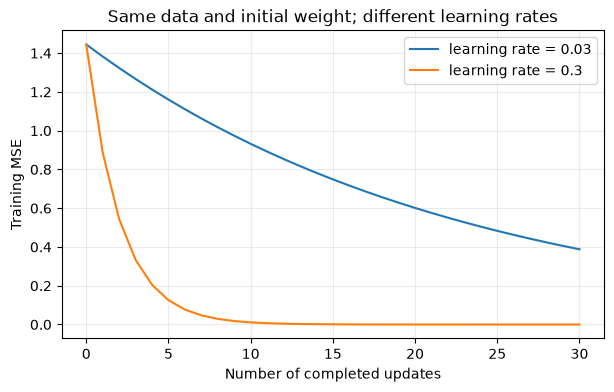

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for lr, history in guide_results.items():
    ax.plot(np.arange(len(history)), history, label=f"learning rate = {lr}")
ax.set(xlabel="Number of completed updates", ylabel="Training MSE",
       title="Same data and initial weight; different learning rates")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Open TensorBoard in Colab

Run the next cell. Select both runs and open **Scalars** or **Time Series**.
Find `train_mse` and set smoothing to 0 when comparing exact values.

If the panel stays blank, rerun the cell or refresh the dashboard.
The plot above is a fallback while the instructor helps.
The embedded dashboard may not survive downloading the notebook; ordinary plots and printed outputs do.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir $GUIDE_LOG_DIR

## End of the guided part

Before opening the assignment, explain these three points to a neighbour:

1. Why does `features.mean(axis=0)` produce two numbers?
2. What is the difference between a weight, a gradient, and a learning rate?
3. Does a low training loss prove good performance on new recordings?

Open **02_BME_DL_Lab1_Assignment.ipynb** now. It has its own setup and does not require this runtime's variables.

## Optional reference A · Shape changes and copies

`reshape` preserves the number of elements. A transpose reorders axes, including in arrays with more than two dimensions.
For a one-dimensional array, `.T` leaves the shape unchanged; add an axis to make a column.

Basic slices commonly share data with the source array. Use `.copy()` when you need an independent numeric array.

In [11]:
a = np.arange(12, dtype=np.float32).reshape(3, 4)
print("Original:", a.shape, "| reshaped:", a.reshape(2, 6).shape)
cube = a.reshape(2, 2, 3)
print("3D transpose:", cube.transpose(2, 0, 1).shape)
vector = np.arange(4)
print("1D transpose:", vector.T.shape, "| column:", vector[:, None].shape)

view = a[:, :2]
independent = a[:, :2].copy()
view[0, 0] = -99
print("Source changed through the slice:", a[0, 0])
print("Independent copy stayed unchanged:", independent[0, 0])

Original: (3, 4) | reshaped: (2, 6)
3D transpose: (3, 2, 2)
1D transpose: (4,) | column: (4, 1)
Source changed through the slice: -99.0
Independent copy stayed unchanged: 0.0


## Optional reference B · Randomness and an image tensor

`np.random.default_rng(seed)` gives a local random generator. Recreating it with the same seed
repeats the sequence in this environment; successive draws from one generator are different.
A seed alone does not guarantee identical results across every library version, device, or operation.

The image below is synthetic noise. TensorFlow image summaries use
`(batch, height, width, channels)`, which differs from some other logging APIs.

Same seed, first draw: True
Same generator, next draw: [ 0.6383 -0.292  -0.3119  0.3038]
Image summary shape: (1, 16, 16, 1)


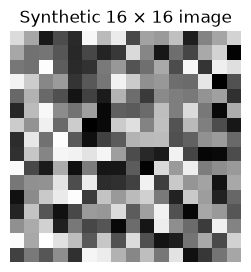

In [12]:
rng_a = np.random.default_rng(2026)
rng_b = np.random.default_rng(2026)
first = rng_a.normal(size=4)
second = rng_a.normal(size=4)
print("Same seed, first draw:", np.allclose(first, rng_b.normal(size=4)))
print("Same generator, next draw:", second)

noise_image = rng_a.random((16, 16), dtype=np.float32)
plt.figure(figsize=(3, 3))
plt.imshow(noise_image, cmap="gray", vmin=0, vmax=1)
plt.title("Synthetic 16 × 16 image")
plt.axis("off")
plt.show()

image_writer = tf.summary.create_file_writer(str(GUIDE_LOG_DIR / "optional_image"))
with image_writer.as_default():
    tf.summary.image("synthetic_noise", noise_image[None, :, :, None], step=0)
image_writer.flush()
image_writer.close()
print("Image summary shape:", noise_image[None, :, :, None].shape)

## Optional reference C · What if the learning rate is too large?

Try `fit_and_log(3.0, steps=15)` and plot its history.
Explain whether the updates approach the minimum or move away.
Large learning rates can cause divergence; different data scales change the safe range.

Other useful references: `np.concatenate` joins arrays along an existing axis;
`np.zeros` creates initialised zeros.
`np.empty` contains uninitialised values and must be filled before use.
Calling `gc.collect()` is not a general solution for freeing a deep learning framework's GPU memory.

## Sources and attribution

Revised for the BME MSc Deep Learning lab, 9 September 2026, for Dr. Mohammed Salah Al-Radhi.
The examples and exercises here use small synthetic data.

Adapted from the 2025 **Deep learning / VITMMA19** materials at Budapest University of Technology and Economics:

- [Python and NumPy basics](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/01_Python_Numpy_basics.ipynb)
- [TensorBoard basics](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/02_TensorBoard_basics_TensorboardX_en.ipynb)
- [TensorFlow operations](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/03_tf_basic_operations.ipynb)

The original notebooks credit Mohammed Salah Al-Radhi, Tamás Gábor Csapó, Márk Császár,
András Kalapos, and Bálint Gyires-Tóth across the three files.
Their original reuse condition is retained: any reuse or publication of any part of the notebook requires the authors' written consent.

Official references, checked 7 September 2026:

- [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html),
  [indexing](https://numpy.org/doc/stable/user/basics.indexing.html), and
  [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html).
- [NumPy Generator](https://numpy.org/doc/stable/reference/random/generator.html),
  [transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html), and
  [NumPy 2 migration](https://numpy.org/doc/stable/numpy_2_0_migration_guide.html).
- [TensorFlow tensors](https://www.tensorflow.org/guide/tensor) and
  [automatic differentiation](https://www.tensorflow.org/guide/autodiff).
- [TensorBoard in notebooks](https://www.tensorflow.org/tensorboard/get_started),
  [summary writer](https://www.tensorflow.org/api_docs/python/tf/summary/create_file_writer), and
  [scalar summaries](https://www.tensorflow.org/api_docs/python/tf/summary/scalar).
- [Colab FAQ](https://research.google.com/colaboratory/faq.html).